# PSD for PSR noise OU process


This notebook compares the PSD defined by an OU process with in the PSD that is typically used in pulsar timing for pulsar timing noise.

We then use these comparisons to set approximate, order-of-magnitude estimates on typical values of our model parameters.

The "traditional" PSD typically used by pulsar people has the same form (i.e. a power law) for both timing noise and the stochastic GW background


$$ P(f) = \frac{A^2}{12 \pi^2} \left( \frac{f}{f_{\text{yr}}}\right)^{-\alpha} [\text{Units: } \text{yr}^{3}]$$ 

Note that sometimes the amplitude is defined differently, with the $12\pi^2$ factor being absorbed, e.g Equation 14 of [Chamberlin et al. 2014](https://arxiv.org/abs/1410.8256), although the modern convention seems to be to leave the factor unabsorbed, e.g. [Reardon et al. 2023](https://arxiv.org/abs/2306.16215). The convention is also to have the amplitude $A$ be _dimensionless_ and the PSD to have units of yr$^3$. When people quote the PSD amplitude in the literature they are referring to this dimensionless amplitude - this will be important to note later w.r.t unit conversion. 

Some other useful literature:
* https://github.com/vallis/libstempo/blob/master/libstempo/toasim.py#L298 
* Equation 7.13 (mind the units!) from https://arxiv.org/pdf/2105.13270 
* Equation 1 in https://arxiv.org/pdf/2306.16229


---

# Derivation of PSD for Time Fluctuations from Ornstein-Uhlenbeck Process

## Starting with the Ornstein-Uhlenbeck SDE
We begin with the Ornstein-Uhlenbeck stochastic differential equation:

$$\frac{dx}{dt} = -\gamma x + \chi(t;\sigma)$$

where $\chi(t;\sigma)$ is white noise with standard deviation $\sigma$.

## PSD of the Ornstein-Uhlenbeck process
Converting to the frequency domain using the Fourier transform:

$$i\omega\tilde{x}(\omega) = -\gamma\tilde{x}(\omega) + \tilde{\chi}(\omega)$$

Solving for $\tilde{x}(\omega)$:

$$\tilde{x}(\omega) = \frac{\tilde{\chi}(\omega)}{i\omega + \gamma}$$

The PSD of $x$ is then:

$$S_x(\omega) = |\tilde{x}(\omega)|^2 = \frac{|\tilde{\chi}(\omega)|^2}{|i\omega + \gamma|^2} = \frac{\sigma^2}{\omega^2 + \gamma^2}$$

Converting to frequency $f$ where $\omega = 2\pi f$:

$$S_x(f) = \frac{\sigma^2}{(2\pi f)^2 + \gamma^2}$$

This can be rewritten as:

$$S_x(f) = \frac{\sigma^2/\gamma^2}{1 + (f/f_c)^2}$$

where $f_c = \gamma/(2\pi)$ is the corner frequency.

## PSD of phase fluctuations $\phi$
Given that $\frac{d\phi}{dt} = x$, in the frequency domain:

$$\tilde{x}(f) = i2\pi f \cdot \tilde{\phi}(f)$$

For power spectral densities, this means:

$$S_x(f) = (2\pi f)^2 \cdot S_{\phi}(f)$$

Rearranging and substituting the expression for $S_x(f)$:

$$S_{\phi}(f) = \frac{S_x(f)}{(2\pi f)^2} = \frac{\sigma^2/\gamma^2}{(2\pi f)^2 \cdot [1 + (f/f_c)^2]}$$

Simplifying:

$$S_{\phi}(f) = \frac{\sigma^2}{\gamma^2} \cdot \frac{1}{(2\pi f)^2 [1 + (f/f_c)^2]}$$

## PSD of time fluctuations $\delta t$
Given $\delta t = \phi/f_0$ where $f_0$ is a constant:

$$S_{\delta t}(f) = \left(\frac{1}{f_0}\right)^2 \cdot S_{\phi}(f)$$

Substituting the expression for $S_{\phi}(f)$:

$$S_{\delta t}(f) = \frac{\sigma^2}{(f_0\gamma)^2(2\pi)^2} \cdot \frac{1}{f^2 [1 + (f/f_c)^2]}$$

With $f_c = \gamma/(2\pi)$ remaining the corner frequency.

This PSD has:
- A $1/f^2$ behavior at low frequencies ($f \ll f_c$)
- A $1/f^4$ behavior at high frequencies ($f \gg f_c$)
- Units of s²/Hz



Note that the paper quotes a denominator of 48. I think this is wrong and it should actually be 24. **Edit** in the paper we haev two different expressions for $\sigma^2$. In Equation 19, we have it over 6, in equation A25, we have it over 12.

In [12]:
import numpy as np


# Constants and unit conversions
seconds_per_year = 365.25 * 24 * 60 * 60  # seconds in a year

def power_law_psd(f, A, alpha):
    """Traditional PSD model: P(f) = A^2/(12*pi^2) * (f/f_ref)^(-alpha) [yr^3]"""

    #First calculate in yr^{3}
    f_ref = 1/seconds_per_year
    psd_yr = (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) 

    # Converting from yr^3 to s^3 for consistency
    return psd_yr * seconds_per_year**3


def ou_psd(f, sigma, gamma, f0):
    """PSD derived from OU process: S_delta_t(f) = sigma^2/((f0*gamma)^2*(2*pi)^2) * 1/(f^2[1 + (f/fc)^2]) for pulsar timing noise"""
    fc = gamma / (2 * np.pi)
    TN = (sigma**2 / (gamma**2 * (2 * np.pi)**2)) * (1 / (f**2 * (1 + (f/fc)**2))) 
    return TN / f0**2


def get_par_value(filename, parameter):
    """Get the value of a parameter from a parameter file.
    
    TK note: It feels like there should be a better way to do this, just using the enterprise.pulsar.Pulsar object.
    However, I have not been able to figure out how to do this yet.
    We require F0 as part of the measurement model. 
    I take it as a known parameter.
    """
    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts or parts[0].startswith('#'):  # skip empty or commented lines
                continue
            if parts[0] == parameter:
                return float(parts[1])  # assumes the value is the second item
    return None  # if the parameter isn't found




# Mock data comparison


For these pulsars, lets seem how well the OU process can approximate their PSD

In [13]:

def objective_function(params, f, y_true,f0):
    sigma, gamma = params
    
    # Calculate the output of your ou_psd function
    y_pred = ou_psd(f, sigma, gamma,f0) 
    
    # Use log space for PSD comparison to handle scale differences
    log_diff = np.log10(y_pred) - np.log10(y_true)
    return np.sum(log_diff**2)  # Return MSE in log space





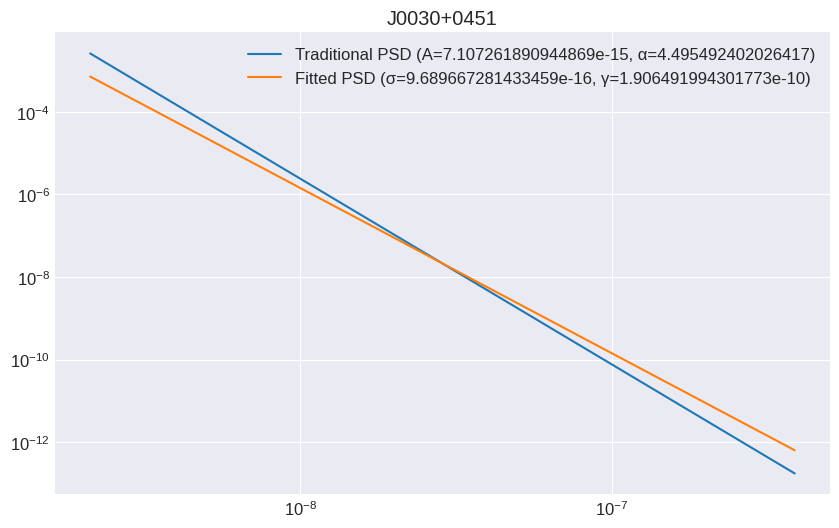

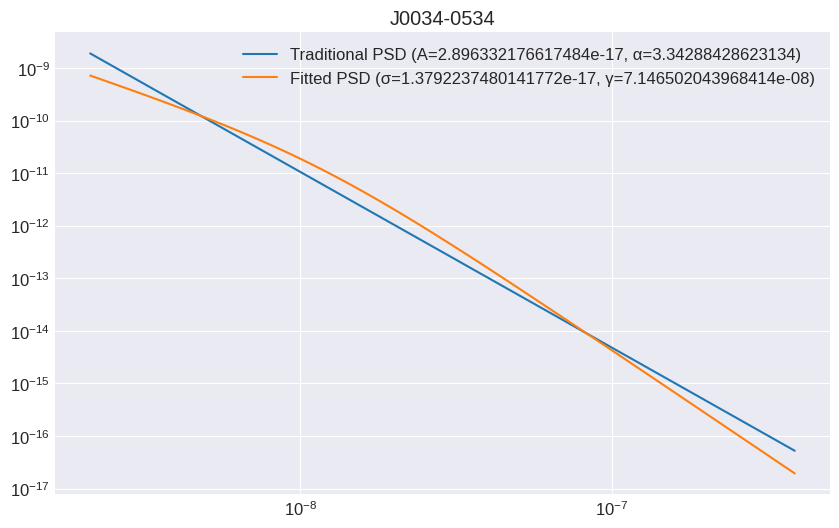

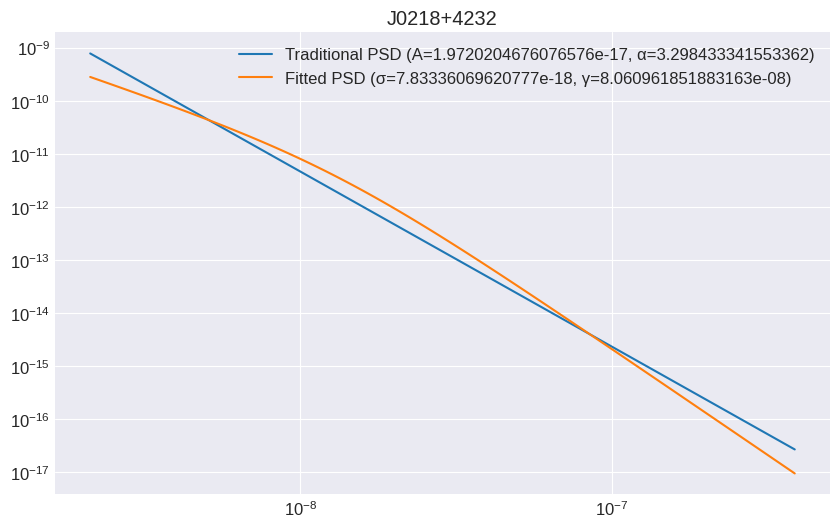

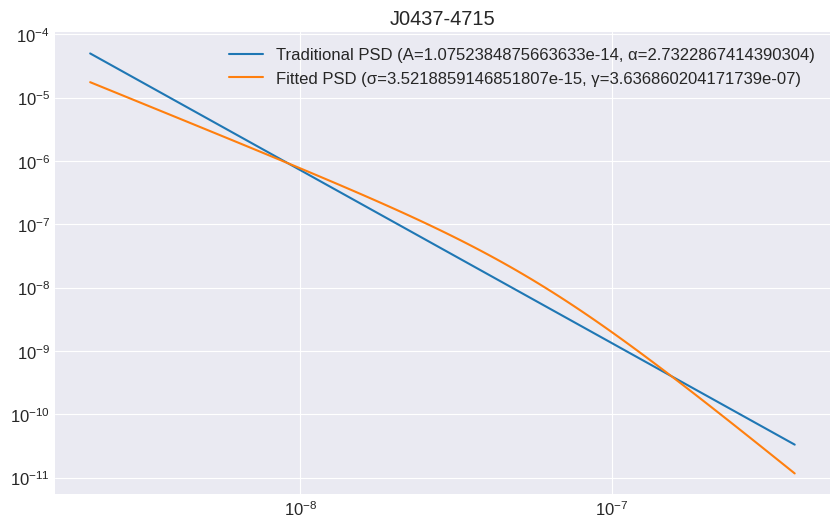

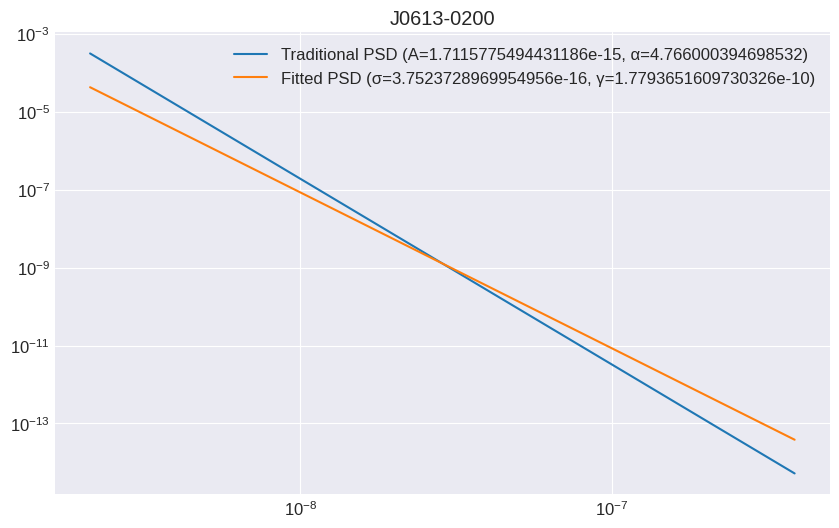

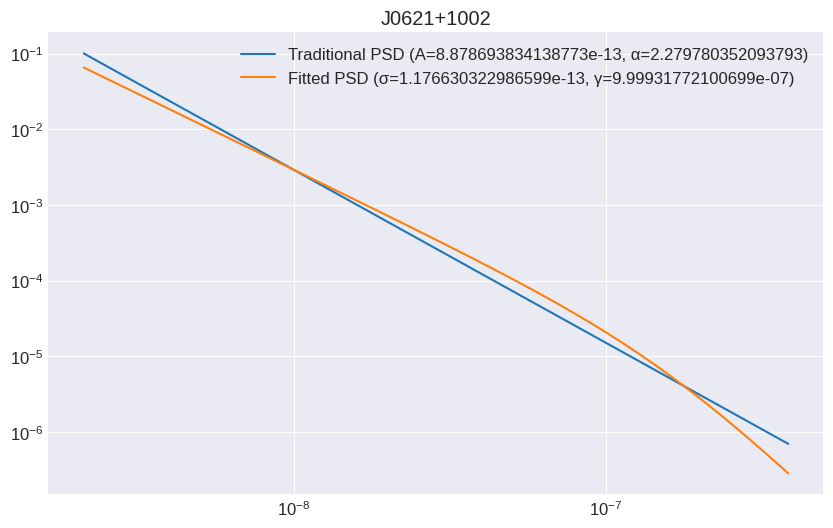

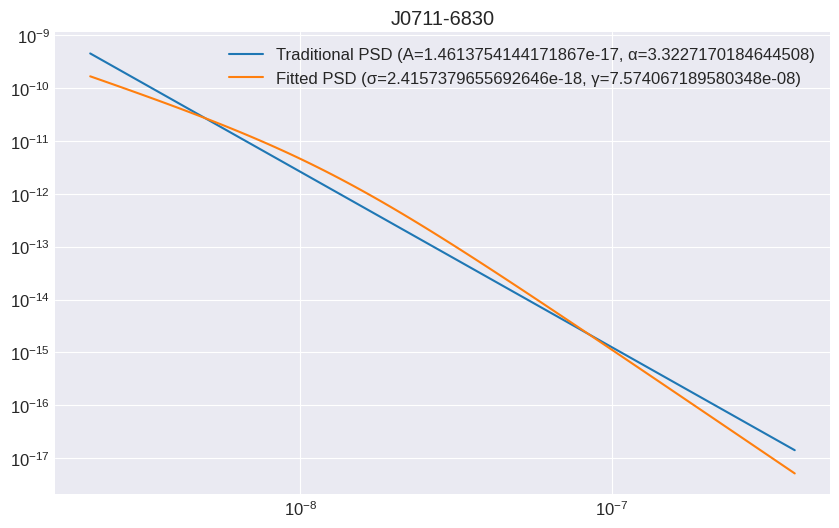

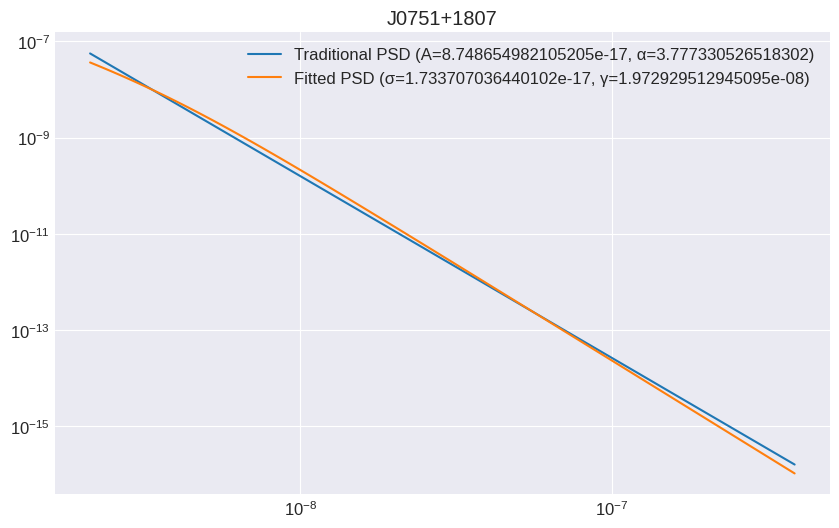

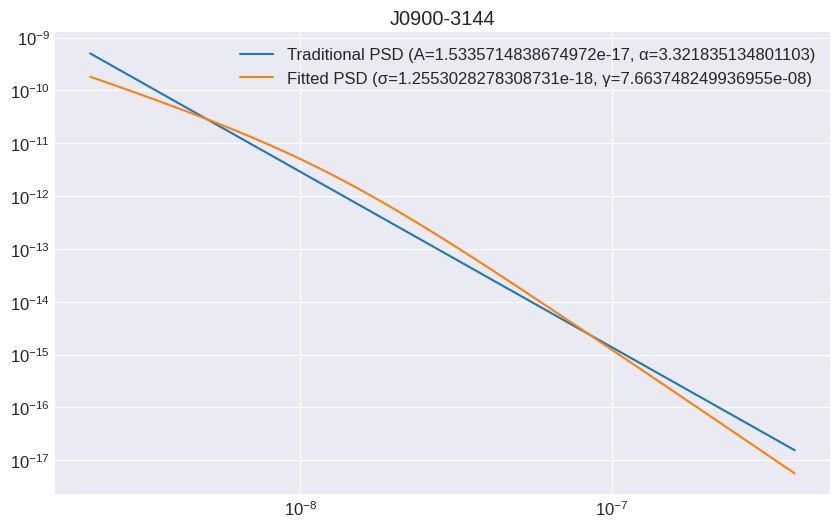

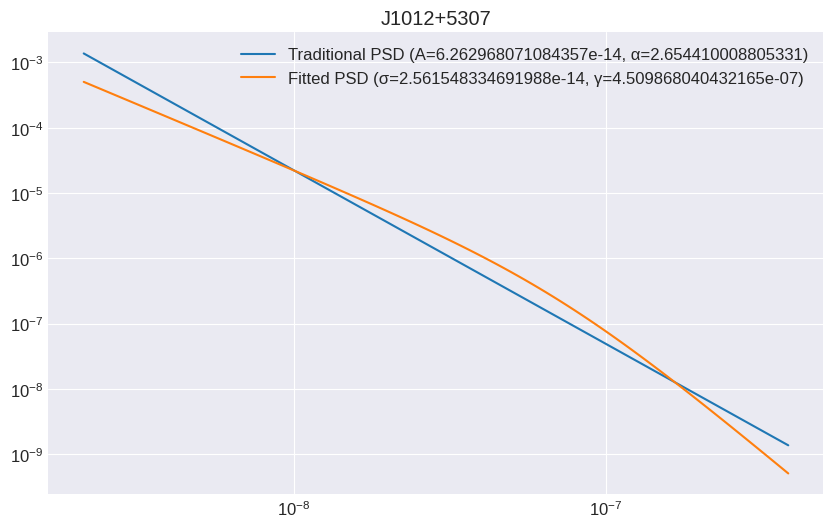

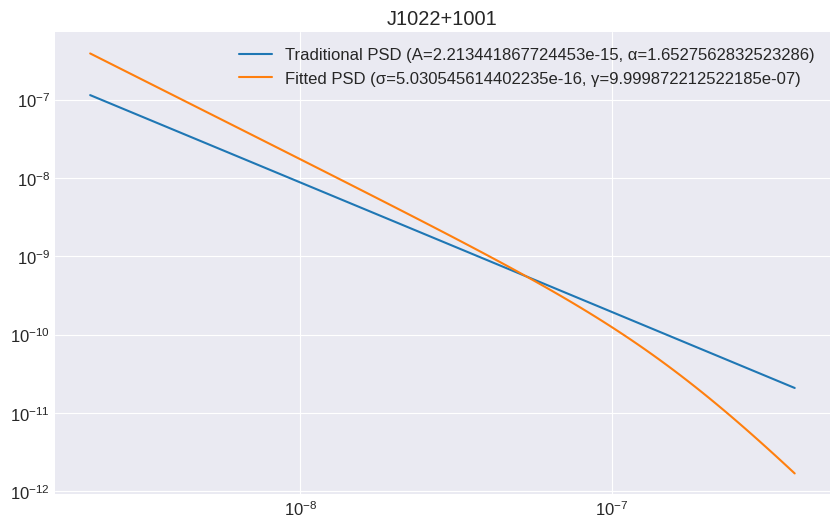

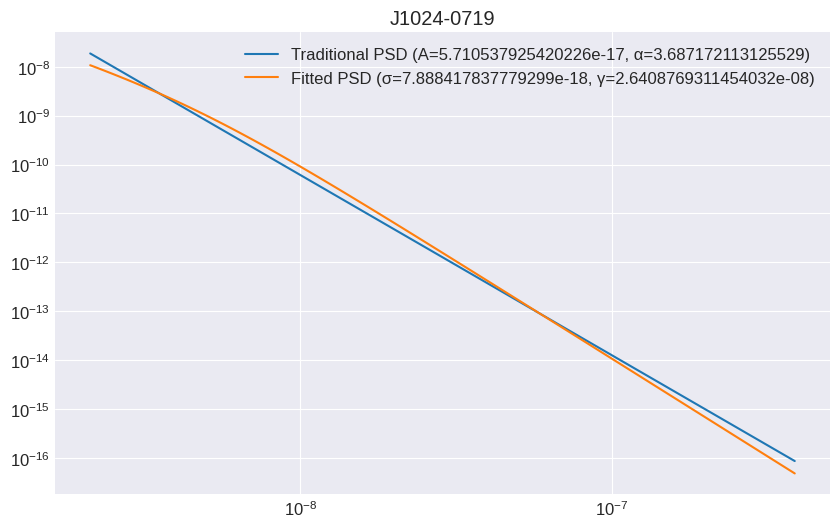

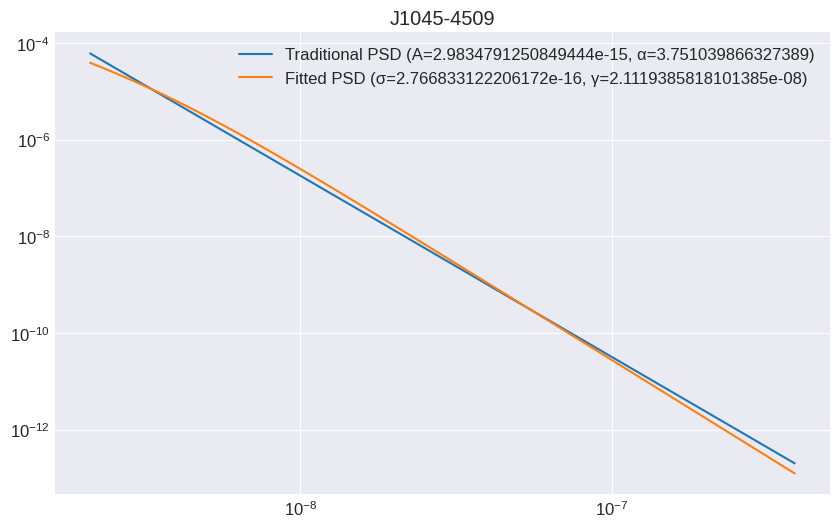

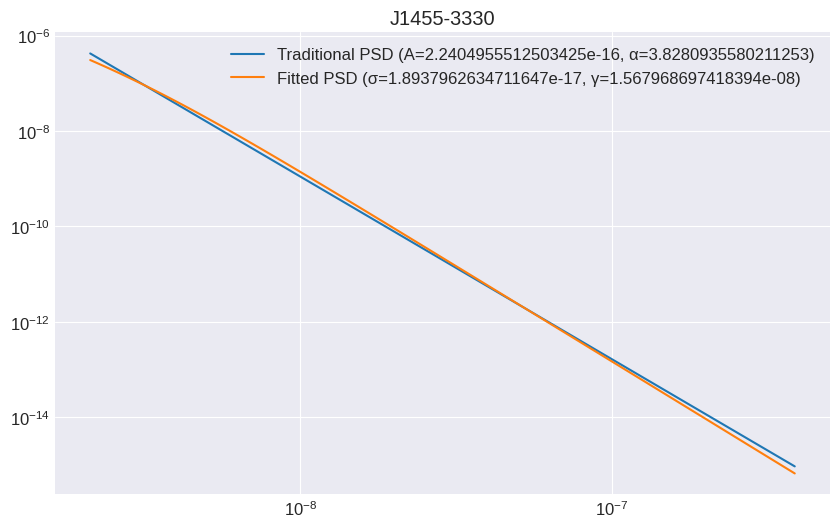

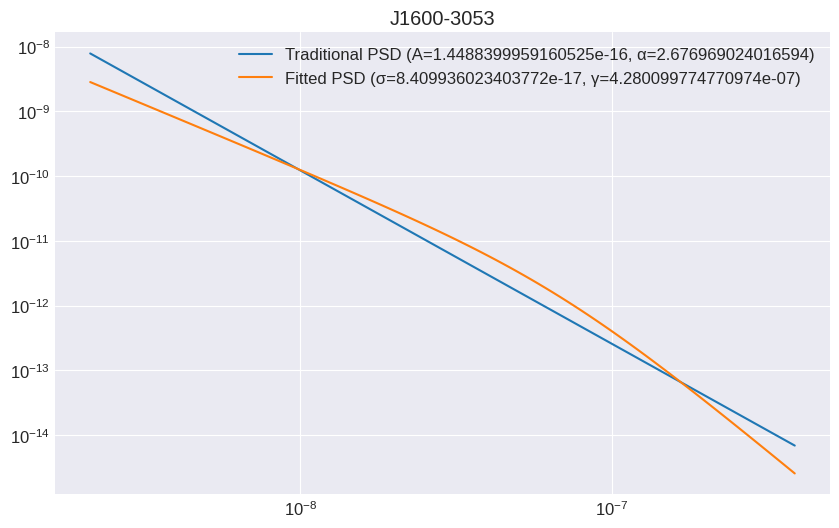

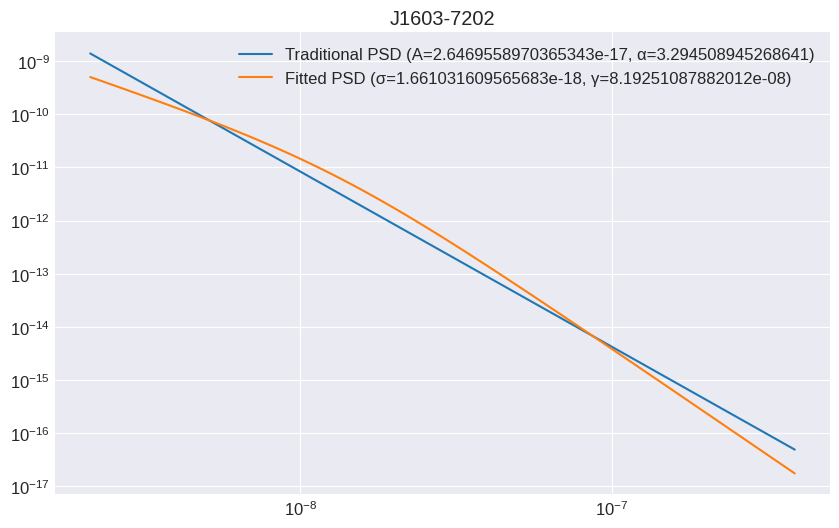

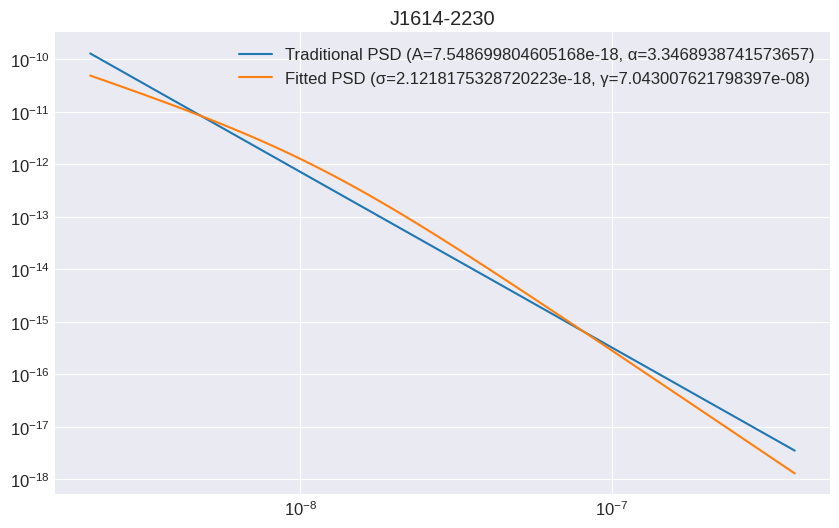

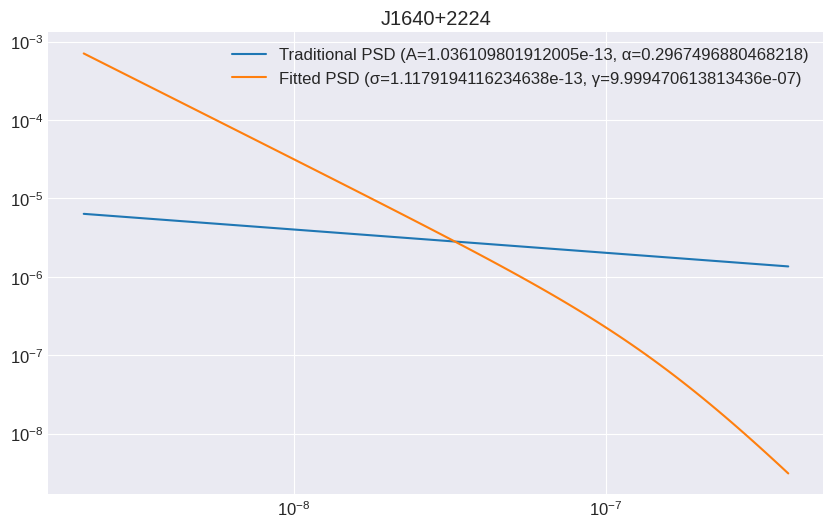

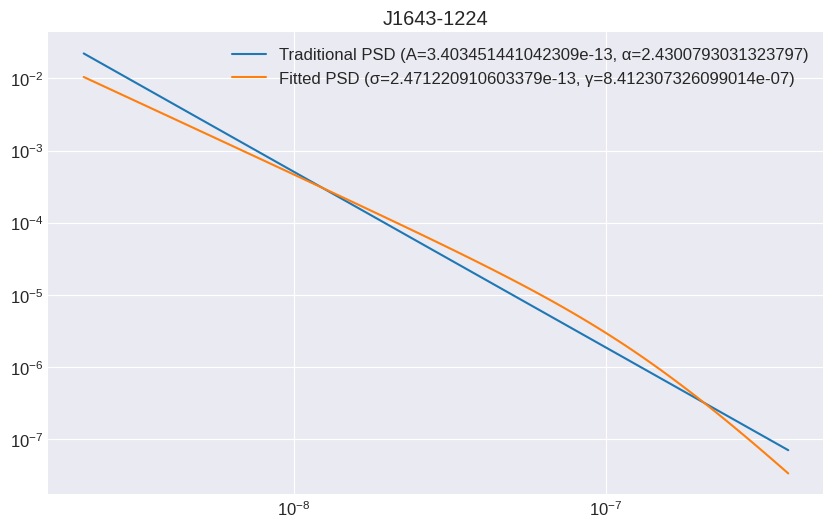

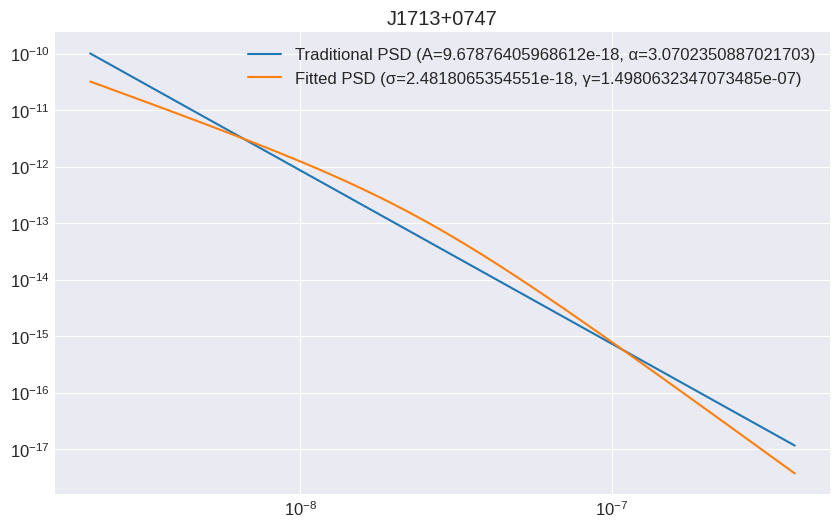

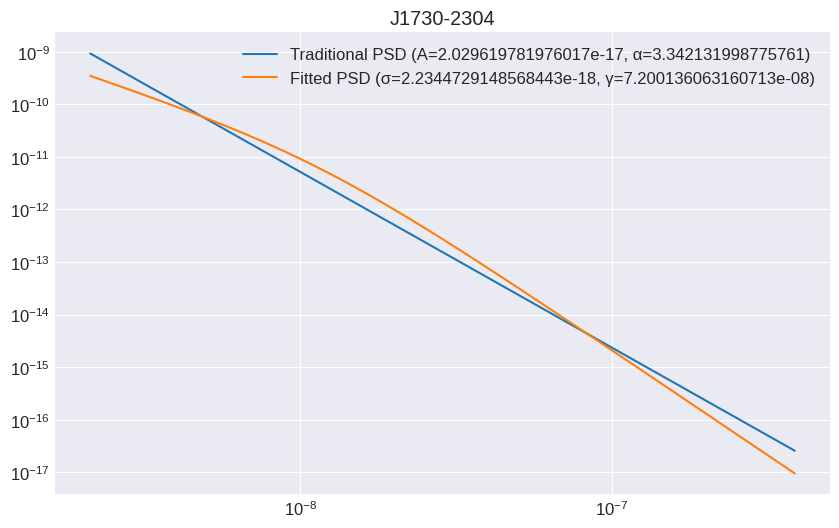

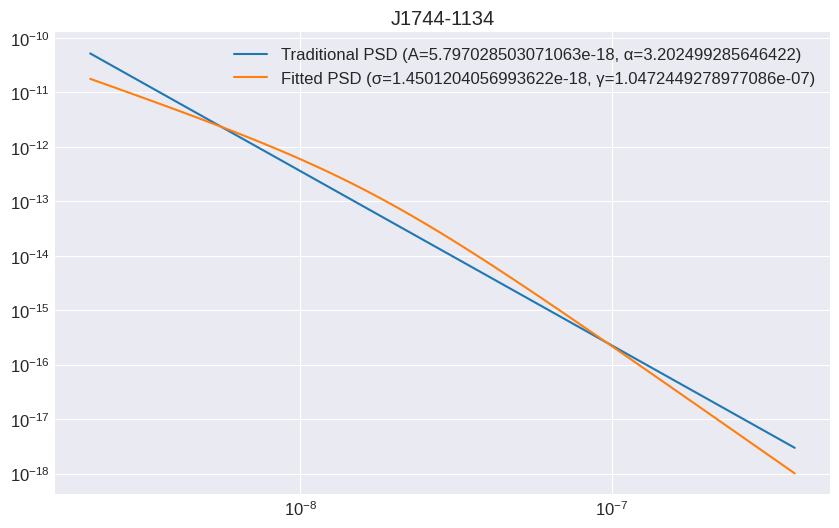

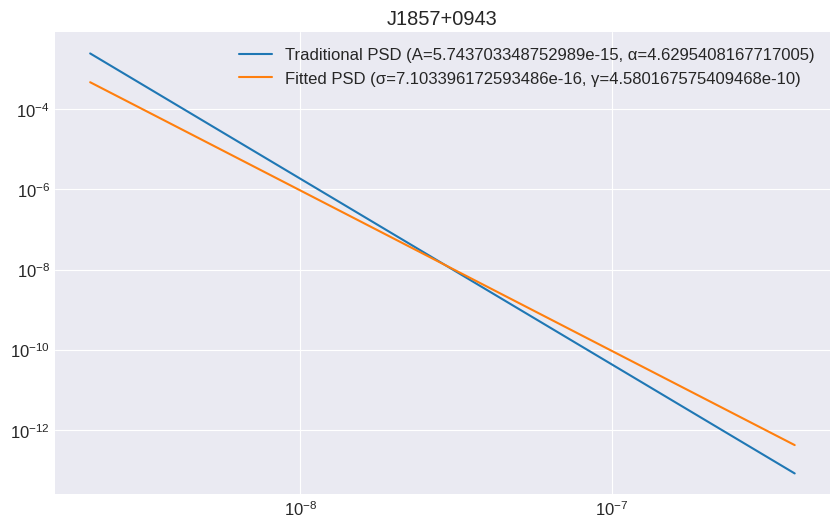

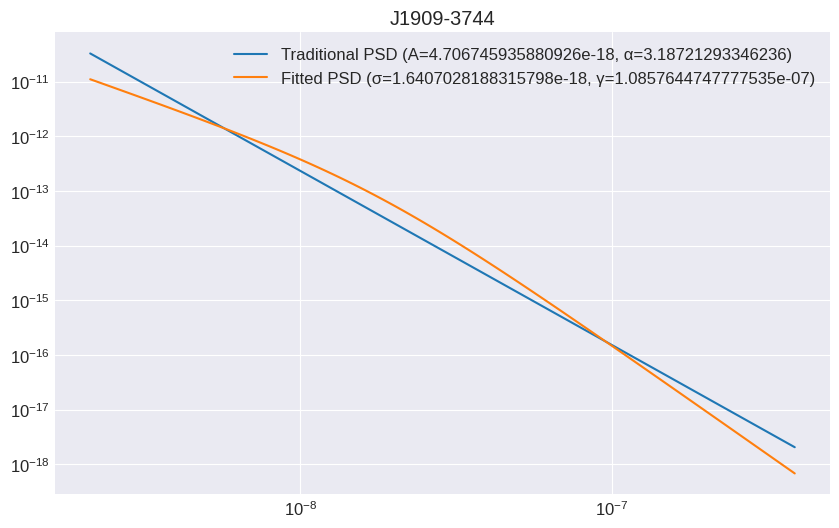

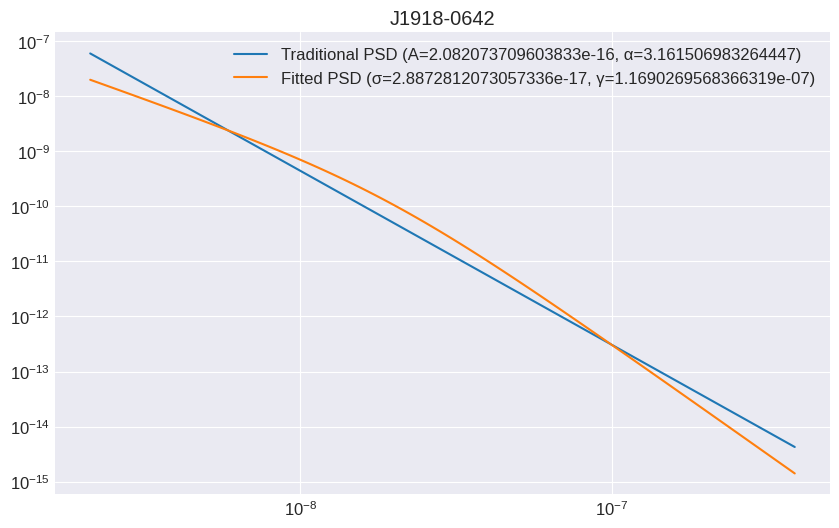

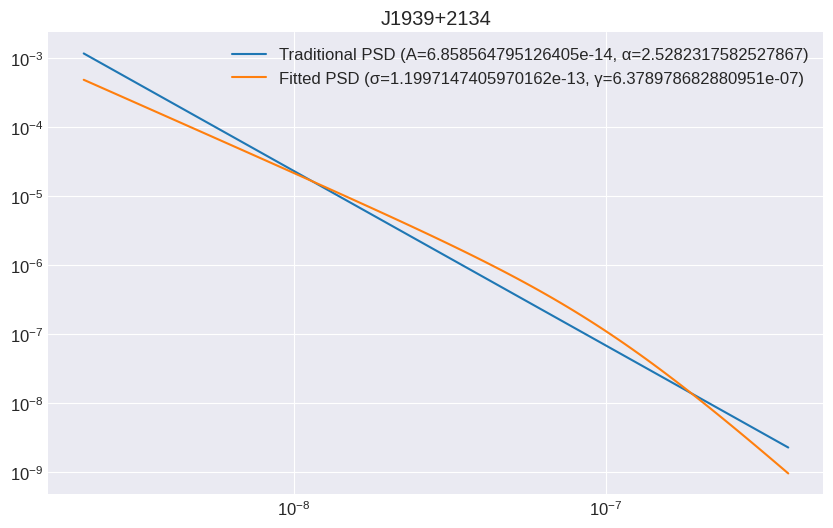

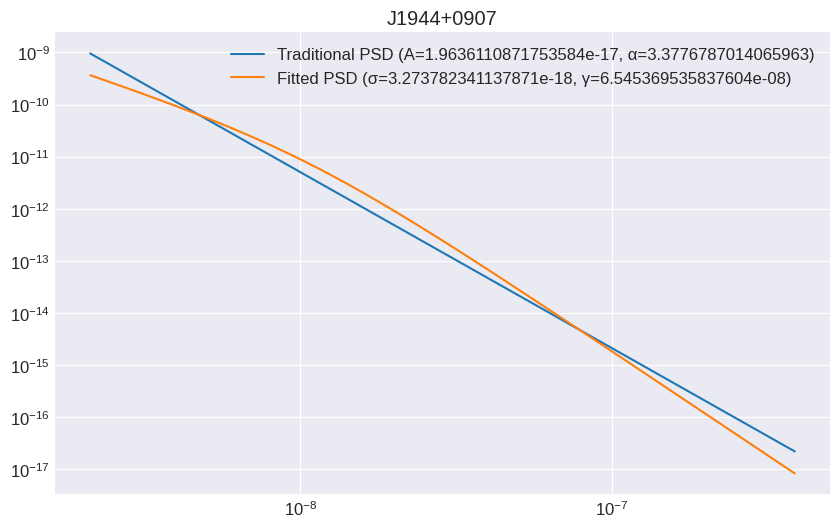

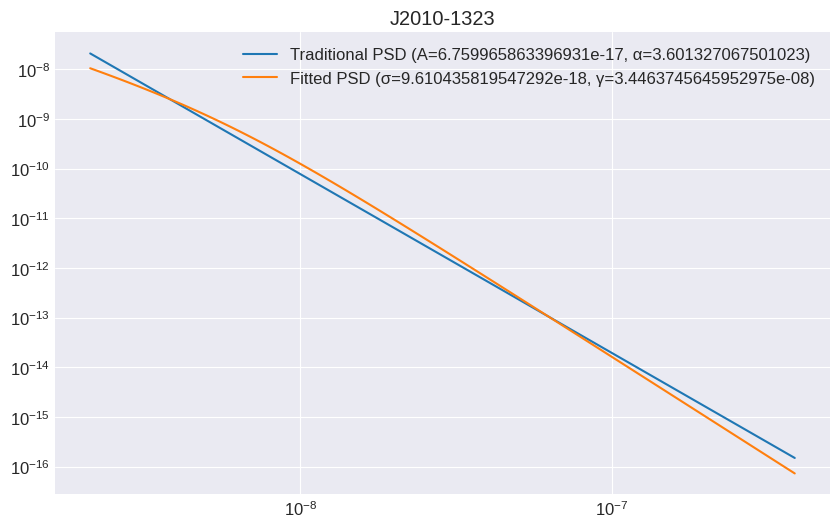

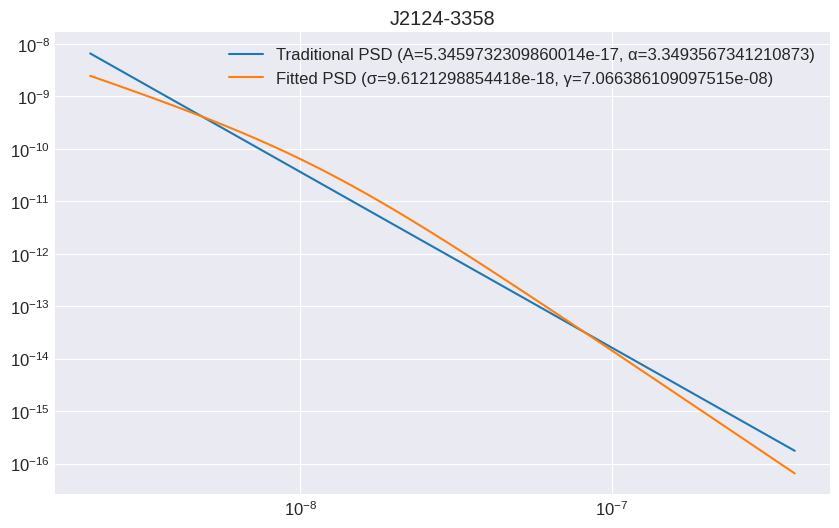

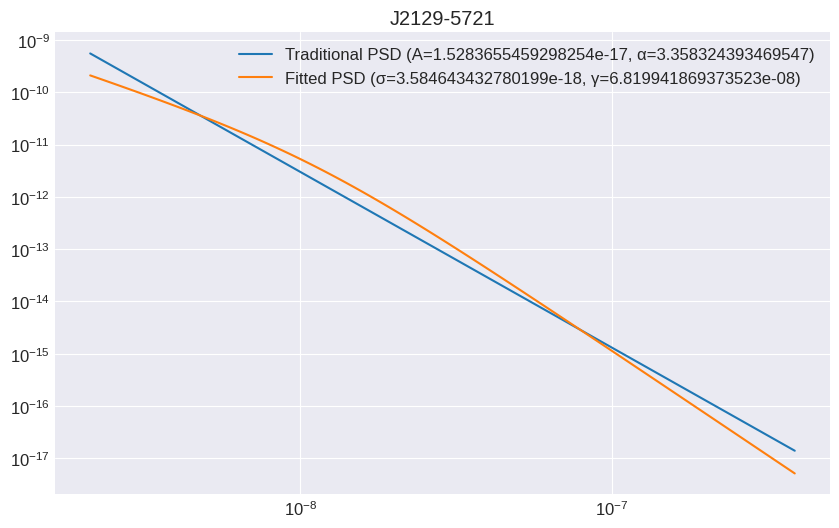

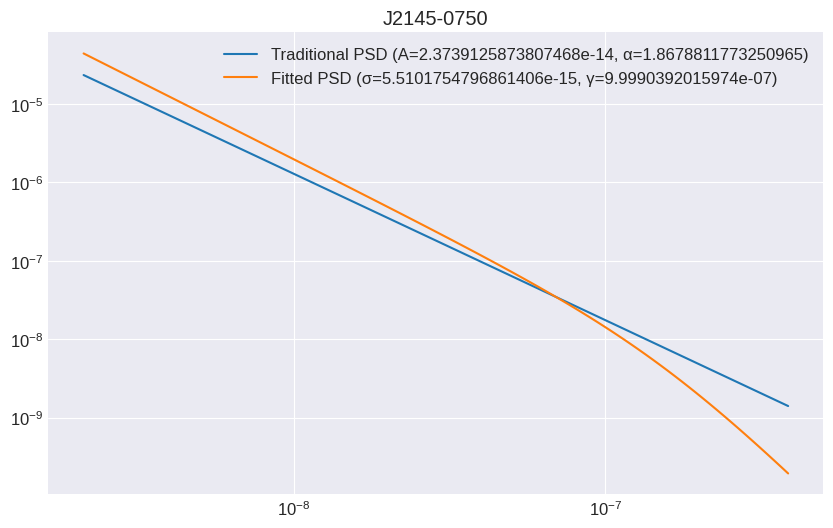

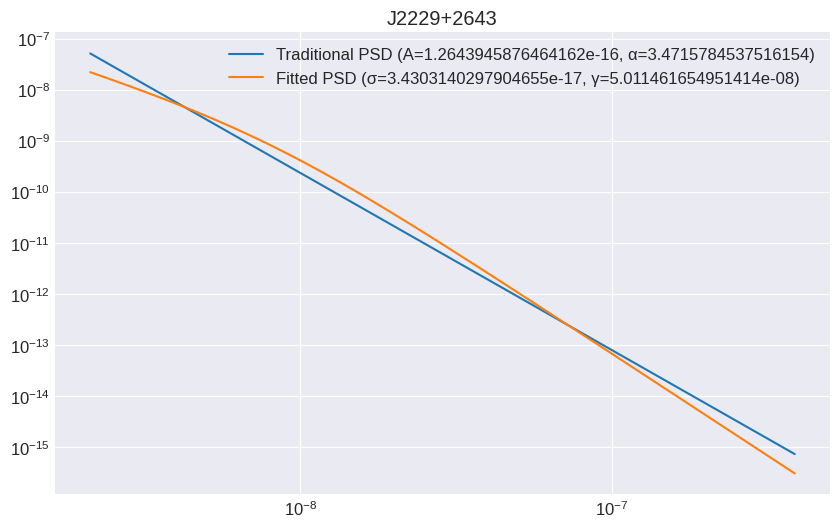

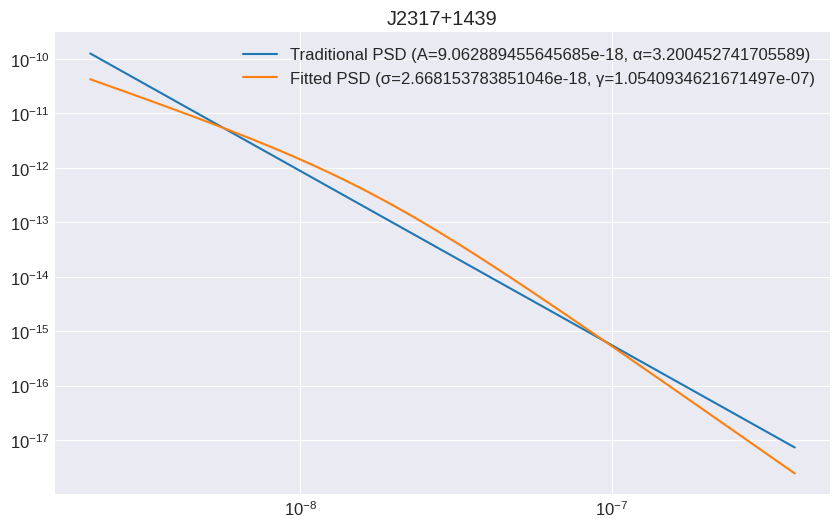

In [ ]:
import json 


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl
from itertools import islice
plt.style.use('seaborn-v0_8-darkgrid')
from scipy import optimize
from scipy.optimize import differential_evolution



f_week = 1/604800.0
f_month = 1/(30.0*24*60*60)
f_year = 1 / (1.0 * 31536000.0) # Let's use 1 / (1 year) for clarity? Or keep original? Let's keep original for now.
f_fifteen_yr = 1/(15*31536000.0) # More descriptive name



datadir = "../data/IPTA_MockDataChallenge2/"
f_range = np.logspace(np.log10(f_month), np.log10(f_fifteen_yr), 100)


# Initial guess for parameters
initial_params = [1e-15, 1e-13]  # [sigma, gamma]

# Define bounds for parameters (if needed)
bounds = [(1e-25, 1e-5), (1e-15, 1e-6)]  # Both sigma and gamma should be positive



import pandas as pd
data = {
    'psr': [],
    'f0': [],
    'optimal_sigma': [],
    'optimal_gamma': [],
    'result_fun': [],
    'EFAC': [],
    'EQUAD': []
}
with open(datadir + "group1_psr_noise.json", "r") as f:
    psd_data = json.load(f)

    for psr,values in psd_data.items():

        plt.figure()
        f0 = get_par_value(datadir + f"dataset_1b/{psr}.par", "F0")
        #print(psr,f0, values)

        A = 10**(values["rn_log10_A"])
        alpha = values["rn_spec_ind"]
        psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

        
        result = differential_evolution(
            objective_function,
            bounds,
            args=(f_range, psd_trad, f0),
            strategy='best1bin',
            maxiter=100,
            popsize=15,
            tol=0.01,
            mutation=(0.5, 1.0),
            recombination=0.7,
            updating='immediate',
            disp=False
        )



        # Get the optimized parameters
        optimal_sigma, optimal_gamma = result.x

      

        # Store the values
        data['psr'].append(psr)  # string
        data['f0'].append(float(f0))
        data['optimal_sigma'].append(float(optimal_sigma))
        data['optimal_gamma'].append(float(optimal_gamma))
        data['result_fun'].append(float(result.fun))
        data['EFAC'].append(float(values["efac"]))
        data['EQUAD'].append(float(values["equad"]))

        plt.loglog(f_range, psd_trad, label=f'Traditional PSD (A={A}, α={alpha})')

        y_fitted = ou_psd(f_range, optimal_sigma, optimal_gamma,f0)
        plt.loglog(f_range, y_fitted, label=f'Fitted PSD (σ={optimal_sigma}, γ={optimal_gamma})')
        plt.title(psr)
        plt.legend()
        plt.show()


df = pd.DataFrame(data)




## Surface numbers 

In [15]:
df.sort_values('psr', ascending=True, inplace=True)
df 

,psr,f0,optimal_sigma,optimal_gamma,result_fun,EFAC,EQUAD
0,J0030+0451,205.530696,9.689667e-16,1.906492e-10,10.673775,1.132705,-6.734253
1,J0034-0534,532.713429,1.379224e-17,7.146502e-08,5.273803,1.259837,-6.641426
2,J0218+4232,430.461055,7.833361e-18,8.060962e-08,5.643998,1.350186,-6.753753
3,J0437-4715,173.687946,3.521886e-15,3.636860e-07,5.878520,0.902789,-7.350188
4,J0613-0200,326.600562,3.752373e-16,1.779365e-10,25.508528,1.069398,-7.049181
5,J0621+1002,34.657407,1.176630e-13,9.999318e-07,1.812269,1.115945,-6.821375
6,J0711-6830,182.117235,2.415738e-18,7.574067e-08,5.445459,1.033147,-7.007095
7,J0751+1807,287.457854,1.733707e-17,1.972930e-08,0.979414,1.098016,-6.783324
8,J0900-3144,90.011842,1.255303e-18,7.663748e-08,5.453182,1.051487,-6.856396
9,J1012+5307,190.267834,2.561548e-14,4.509868e-07,5.248689,1.024449,-6.822630


In [16]:
df.to_pickle('approximate_spin_injections.pkl')

In [17]:
print("Max sigma: ",df['optimal_sigma'].max())
print("Min sigma: ",df['optimal_sigma'].min())
print("Max gamma: ",df['optimal_gamma'].max())
print("Min gamma: ",df['optimal_gamma'].min())
print("Max EFAC: ",df['EFAC'].max())
print("Min EFAC: ",df['EFAC'].min())
print("Max EQUAD: ",df['EQUAD'].max())
print("Min EQUAD: ",df['EQUAD'].min())


Max sigma:  2.471220910603379e-13
Min sigma:  1.2553028278308731e-18
Max gamma:  9.999872212522185e-07
Min gamma:  1.7793651609730326e-10
Max EFAC:  2.2058139485827803
Min EFAC:  0.9027892928548922
Max EQUAD:  -6.244756338992644
Min EQUAD:  -7.556289609789052


How do these gammas compare to our Tobs timescale of 15 years?

In [24]:
taus = 1/df['optimal_gamma'].values
taus < 1/f_fifteen_yr

array([False,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [26]:
df['optimal_gamma'].values

array([1.90649199e-10, 7.14650204e-08, 8.06096185e-08, 3.63686020e-07,
       1.77936516e-10, 9.99931772e-07, 7.57406719e-08, 1.97292951e-08,
       7.66374825e-08, 4.50986804e-07, 9.99987221e-07, 2.64087693e-08,
       2.11193858e-08, 1.56796870e-08, 4.28009977e-07, 8.19251088e-08,
       7.04300762e-08, 9.99947061e-07, 8.41230733e-07, 1.49806323e-07,
       7.20013606e-08, 1.04724493e-07, 4.58016758e-10, 1.08576447e-07,
       1.16902696e-07, 6.37897868e-07, 6.54536954e-08, 3.44637456e-08,
       7.06638611e-08, 6.81994187e-08, 9.99903920e-07, 5.01146165e-08,
       1.05409346e-07])

In [25]:
taus / seconds_per_year

array([1.66211492e+02, 4.43406965e-01, 3.93105542e-01, 8.71303433e-02,
       1.78086480e+02, 3.16902500e-02, 4.18376112e-01, 1.60614394e+00,
       4.13480281e-01, 7.02638914e-02, 3.16884928e-02, 1.19990778e+00,
       1.50042658e+00, 2.02096431e+00, 7.40358624e-02, 3.86793357e-01,
       4.49922668e-01, 3.16897654e-02, 3.76687234e-02, 2.11527038e-01,
       4.40104014e-01, 3.02585259e-01, 6.91854333e+01, 2.91850475e-01,
       2.71063791e-01, 4.96758014e-02, 4.84129852e-01, 9.19461516e-01,
       4.48434141e-01, 4.64638679e-01, 3.16911327e-02, 6.32312287e-01,
       3.00619337e-01])

# The troublesome pulsar: J1640+2224

f_week: 1.65e-06 Hz
f_month: 3.86e-07 Hz
f_fifteen_yr: 2.11e-09 Hz
J1640+2224 316.1239793318562
1.036109801912005e-13


Text(0, 0.5, 'P(f) [s^3]')

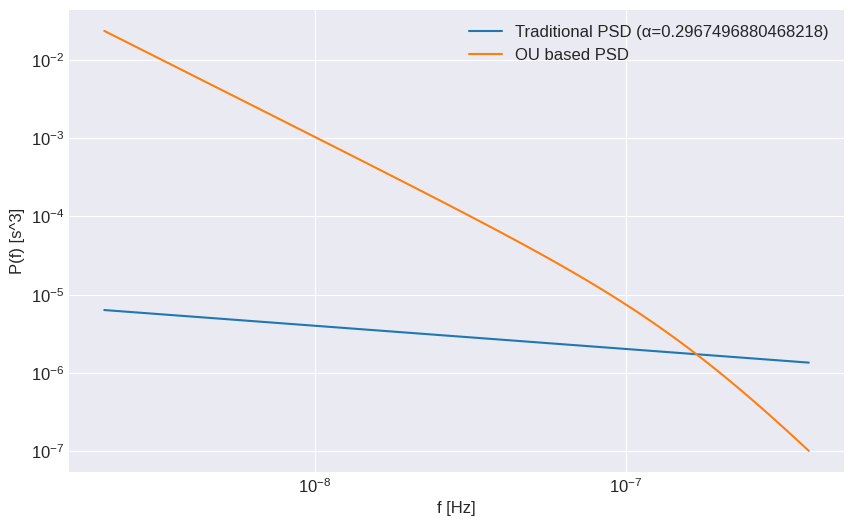

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl
import json 

datadir = "../data/IPTA_MockDataChallenge2/"



print(f"f_week: {f_week:.2e} Hz")
print(f"f_month: {f_month:.2e} Hz")
print(f"f_fifteen_yr: {f_fifteen_yr:.2e} Hz")

# Use f_month and f_fifteen_yr for the plotting range ends
f_range = np.logspace(np.log10(f_month), np.log10(f_fifteen_yr), 100)



#Select a PSR and get its parameters

import sys
psr_name = 'J1640+2224'
with open(datadir + "group1_psr_noise.json", "r") as f:
    psd_data = json.load(f)
    values = psd_data[psr_name] 
    f0 = get_par_value(datadir + f"dataset_1b/{psr_name}.par", "F0")
    print(psr_name,f0)

    A = 10**(values["rn_log10_A"])
    print(A)
    alpha = values["rn_spec_ind"]
    psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

    #OU
    psd_ou = ou_psd(f=f_range,sigma=6.4e-13,gamma=1e-6,f0=f0) 



#Plot
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')

# Observation cadence

Lets also take a quick look at how the pulsar observations are spaced.

In [27]:
from argus import data_loader 

In [29]:

import glob 
directory = "../data/IPTA_MockDataChallenge2/dataset_2b/"
# Get all .par and .tim files in the directory
par_files = sorted(glob.glob(directory + "*.par"))
tim_files = sorted(glob.glob(directory + "*.tim"))

assert len(par_files) == len(tim_files), "Mismatch between .par and .tim file counts."

#Exclude PR J1640+2224 as it has an exponent which is to small for the OU process to be valid
par_files = [f for f in par_files if "J1640" not in f]
tim_files = [f for f in tim_files if "J1640" not in f]


# Get the data
print(f"Getting the data. Loading {len(par_files)} pulsars from {directory}")
pulsar_residuals, pulsar_metadata, _ , _ = (
    data_loader.LoadWidebandPulsarData.read_multiple_par_tim(par_files, tim_files)
)


Getting the data. Loading 32 pulsars from ../data/IPTA_MockDataChallenge2/dataset_2b/
[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0030+0451, F0: 205.53069593846152, # TOAs: 183
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0034-0534, F0: 532.7134293952242, # TOAs: 183
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0218+4232, F0: 430.46105454575843, # TOAs: 183
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0437-4715, F0: 173.6879457375193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0613-0200, F0: 326.60056202349193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0621+1002 uses DM2+ but does not define DM_SERIES

PSR: J0621+1002, F0: 34.65740662142043, # TOAs: 183
[preProcess.C:158] Warning: PSR J0711-6830 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0711-6830, F0: 182.1172346472276, # TOAs: 183
[preProcess.C:158] Warning: PSR J0751+1807 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0751+1807, F0: 287.4578539950941, # TOAs: 183
[preProcess.C:158] Warning: PSR J0900-3144 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0900-3144, F0: 90.0118419193632, # TOAs: 183
[preProcess.C:158] Warning: PSR J1012+5307 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1012+5307, F0: 190.26783444155498, # TOAs: 183
[preProcess.C:158] Warning: PSR J1022+1001 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1022+1001, F0: 60.779447956696714, # TOAs: 183
[preProcess.C:158] Warning: PSR J1024-0719 uses DM2+ but does not define DM_SERIES.

PSR: J1603-7202, F0: 67.37658112877924, # TOAs: 183
[preProcess.C:158] Warning: PSR J1614-2230 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1614-2230, F0: 317.37893706872126, # TOAs: 183
[preProcess.C:158] Warning: PSR J1643-1224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1643-1224, F0: 216.37333714263485, # TOAs: 183
[preProcess.C:158] Warning: PSR J1713+0747 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1713+0747, F0: 218.81184041715784, # TOAs: 183
[preProcess.C:158] Warning: PSR J1730-2304 uses DM2+ but does not define DM_SERIE

PSR: J1944+0907, F0: 192.85651792018598, # TOAs: 183
[preProcess.C:158] Warning: PSR J2010-1323 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2010-1323, F0: 191.45090909263828, # TOAs: 183
[preProcess.C:158] Warning: PSR J2124-3358 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2124-3358, F0: 202.7938937460303, # TOAs: 183
[preProcess.C:158] Warning: PSR J2129-5721 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2129-5721, F0: 268.3592272938787, # TOAs: 183
[preProcess.C:158] Warning: PSR J2145-0750 uses DM2+ but does not define DM_SERIES

PSR: J2145-0750, F0: 62.29588783738885, # TOAs: 183
[preProcess.C:158] Warning: PSR J2229+2643 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2229+2643, F0: 335.81620819685526, # TOAs: 183
[preProcess.C:158] Warning: PSR J2317+1439 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2317+1439, F0: 290.2546036648635, # TOAs: 183


In [42]:
pulsar_metadata.iloc[0]['name']

'J0030+0451'

In [ ]:
puls

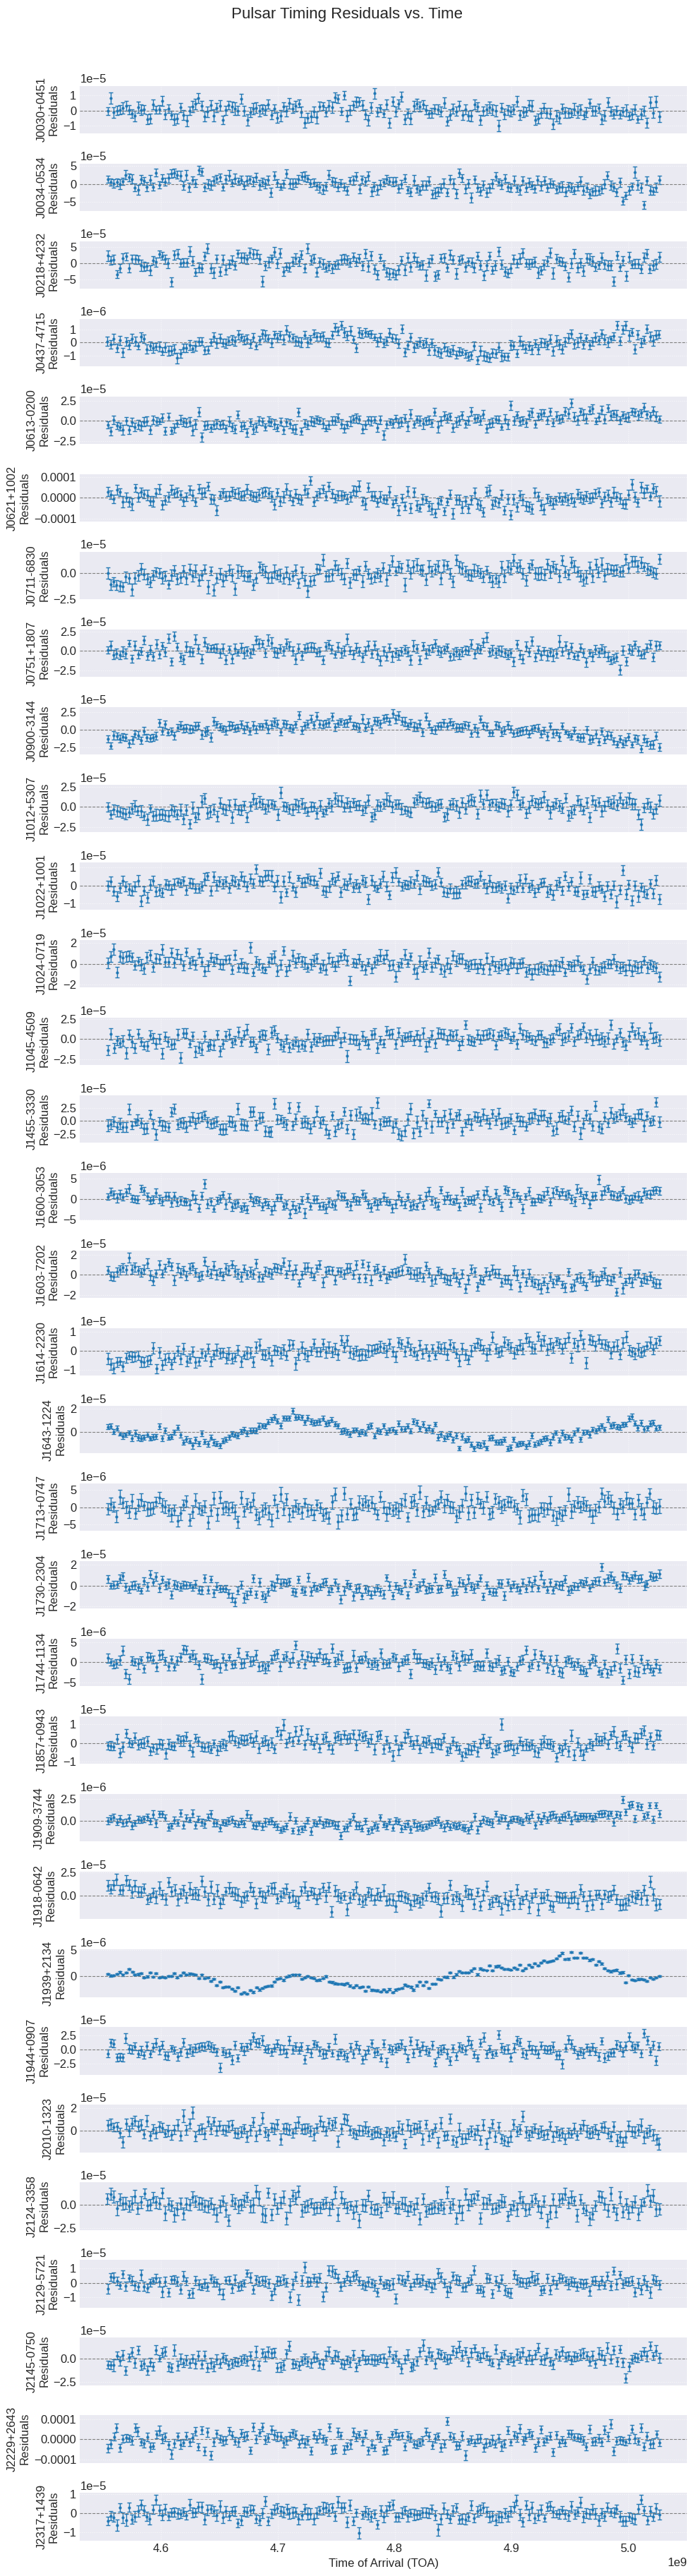

In [44]:
num_pulsars = len(pulsar_residuals)

# Create figure and axes: N rows, 1 column. Share the x-axis.
# Adjust figsize as needed: (width, height) in inches. Height depends on num_pulsars.
fig, axes = plt.subplots(
    num_pulsars, 
    1, 
    sharex=True, 
    figsize=(10, 1.2 * num_pulsars) # Width 10, Height 1.2 inches per pulsar
) 

# Handle the case where there's only one pulsar (axes is not an array)
if num_pulsars == 1:
    axes = [axes] # Make it iterable like the multi-pulsar case

# Common plot parameters for error bars
errorbar_params = {
    'fmt': '.',         # Use dots for markers
    'linestyle': 'none', # No connecting lines
    'markersize': 4,     # Size of the markers
    'elinewidth': 1,     # Thickness of the error bar lines
    'capsize': 2         # Size of the error bar caps
}

# Loop through each DataFrame and corresponding subplot axis
for i, df in enumerate(pulsar_residuals):
    ax = axes[i]
    pulsar_name = pulsar_metadata.iloc[i]['name']

    # Plot residuals vs TOAs with error bars
    ax.errorbar(
        df['toas'], 
        df['residuals'], 
        yerr=df['error'], 
        **errorbar_params
    )
    
    # Set y-axis label for each subplot (pulsar name + Residuals)
    # You might want to add units here, e.g., 'Residuals (us)'
    ax.set_ylabel(f"{pulsar_name}\nResiduals") 
    
    # Add a horizontal line at y=0 for reference
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    
    # Optional: Add grid lines
    ax.grid(True, linestyle=':', alpha=0.7)

# Set x-axis label only for the bottom subplot
# You might want to add units here, e.g., 'Time (MJD)'
axes[-1].set_xlabel("Time of Arrival (TOA)") 

# Add a main title to the figure
fig.suptitle("Pulsar Timing Residuals vs. Time", fontsize=16)

# Adjust layout to prevent labels overlapping
# This might need tweaking depending on label lengths
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect to make space for suptitle

# Display the plot
plt.show()

In [51]:
num_pulsars = len(pulsar_residuals)
    
# 1. Validation: Check if all DataFrames have the same length
first_len = len(pulsar_residuals[0])
if not all(len(df) == first_len for df in pulsar_residuals):
    print("Error: Not all pulsars have the same number of observations.")
    # Decide how to handle this: exit, pad, or proceed with caution?
    # For now, we'll stop.
    exit() 
    
num_observations = first_len
print(f"All {num_pulsars} pulsars have {num_observations} observations.")

# 2. Prepare data: Sort each DF by 'toas' and extract the 'toas' column
sorted_toas_dict = {}
for i, df in enumerate(pulsar_residuals):
    pulsar_name = f"Pulsar {i+1}"
    # Sort by 'toas', reset index to ensure 0 to N-1 order, then get 'toas'
    sorted_toas = df.sort_values(by='toas').reset_index(drop=True)['toas']
    sorted_toas_dict[pulsar_name] = sorted_toas
    
# 3. Create the final DataFrame
# The dictionary keys become column names, lists/Series become column data
grouped_by_observation_num = pd.DataFrame(sorted_toas_dict)

# Display the result
print("\nTOAs grouped by observation number (rows) across pulsars (columns):")
print(grouped_by_observation_num)

All 32 pulsars have 183 observations.

TOAs grouped by observation number (rows) across pulsars (columns):
         Pulsar 1      Pulsar 2      Pulsar 3      Pulsar 4      Pulsar 5  \
0    4.554569e+09  4.554505e+09  4.554601e+09  4.554380e+09  4.554633e+09   
1    4.557013e+09  4.557068e+09  4.556982e+09  4.557093e+09  4.557168e+09   
2    4.559504e+09  4.559707e+09  4.559612e+09  4.559629e+09  4.559708e+09   
3    4.562442e+09  4.562383e+09  4.562330e+09  4.562249e+09  4.562318e+09   
4    4.564798e+09  4.564955e+09  4.564922e+09  4.564908e+09  4.564834e+09   
..            ...           ...           ...           ...           ...   
178  5.015703e+09  5.015873e+09  5.015835e+09  5.015859e+09  5.015829e+09   
179  5.018418e+09  5.018431e+09  5.018295e+09  5.018438e+09  5.018479e+09   
180  5.021130e+09  5.021180e+09  5.021025e+09  5.021129e+09  5.020913e+09   
181  5.023704e+09  5.023592e+09  5.023596e+09  5.023610e+09  5.023543e+09   
182  5.026256e+09  5.026330e+09  5.026267e+09 

In [60]:
grouped_by_observation_num.std(axis=1) / (24*3600) #std in days 


0      0.992299
1      1.026994
2      0.959840
3      1.125416
4      0.964848
         ...   
178    1.258716
179    1.150326
180    0.973689
181    1.097138
182    0.862113
Length: 183, dtype: float64

We are therefore justified in working with batched operations.